#### Assessment: Neural Network Regression using TensorFlow

Instructions:
Complete the following tasks using Google Colab and TensorFlow.

- Dataset Preparation:
Create your own regression dataset (or expand the dataset created in “Create Data to View and Fit”). Build and fit a regression model using this dataset.

- Model Development:
Design a neural network consisting of four (4) Dense layers and train it on your regression dataset. Observe and record its performance.

- Model Improvement:
Apply techniques to improve the model’s accuracy or loss performance. Document any changes made and their effects.

- Visualization:
Create a plot comparing the predicted values and the actual values from your dataset.

- Originality:
Do not replicate the example shown in RegressionExample3. Your model and dataset must be unique.

- Submission:
Upload your completed Google Colab notebook to GitHub and share the repository link for evaluation.

In [87]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [88]:
data = pd.read_csv('/content/sample_data/Employers_data.csv')
data.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [89]:
X = data.drop('Salary', axis=1) # axis=0 (rows), axis=1 (columns)
y = data['Salary']

# Separate numeric and categorical features
num_features = ['Age', 'Experience_Years']
cat_features = ['Gender', 'Department', 'Job_Title', 'Education_Level', 'Location']

In [90]:
# Preprocessing (Depend on data)
num_transformer = StandardScaler() # each numeric feature is resized to the same scale
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

In [91]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
# Convert to tensors later after preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [93]:
# Convert to tensors
X_train = tf.constant(X_train, dtype=tf.float32)
X_test = tf.constant(X_test, dtype=tf.float32)
y_train = tf.constant(y_train.values, dtype=tf.float32)
y_test = tf.constant(y_test.values, dtype=tf.float32)

In [94]:
# Build TensorFlow model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Improved with 4 layers
    tf.keras.layers.Dense(32, activation='relu'), # loss: 3366.2349 Test MAE: 3342.67724609375
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [95]:
# Compile model
model.compile(optimizer='adam', loss='mae')

In [96]:
# Train model
history = model.fit(X_train, y_train, epochs=100, verbose=0)
# epochs=50 is underfit
# epochs=200 is starting overfit

In [97]:
# Evaluate
loss = model.evaluate(X_test, y_test)
print("Test MAE:", loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3354.5754
Test MAE: 3335.135009765625


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


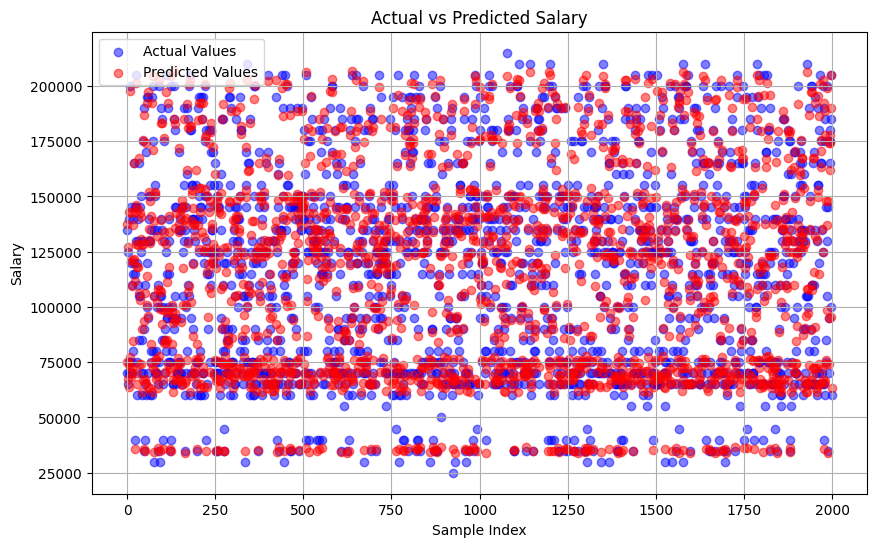

In [98]:
# Generate predictions
y_pred = model.predict(X_test).flatten()

# Scatter actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', alpha=0.5, label='Actual Values')
plt.scatter(range(len(y_pred)), y_pred, color='red', alpha=0.5, label='Predicted Values')

plt.title('Actual vs Predicted Salary')
plt.xlabel('Sample Index')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()
